In [5]:
# imports
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from torch.utils.data import Dataset, DataLoader

In [6]:
# Noise Reduction
def reduce_noise(audio):

    audio = audio - np.mean(audio)

    threshold = np.std(audio) * 0.5

    audio[np.abs(audio) < threshold] = 0

    return audio

In [7]:
# Audio Augmentation
def augment_audio(audio, sr):

    augmented = []

    # Original
    augmented.append(audio)

    # Noise
    noise = np.random.randn(len(audio))
    augmented.append(audio + 0.003 * noise)

    # Time shift
    shift = np.random.randint(sr // 4)
    augmented.append(np.roll(audio, shift))

    # Pitch shift
    try:
        pitch = librosa.effects.pitch_shift(
            audio,
            sr=sr,
            n_steps=np.random.uniform(-1, 1)
        )

        augmented.append(pitch)

    except:
        pass

    return augmented

In [8]:
# Mel Spectrogram Extraction
def extract_mel(audio, sr):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    target_width = 128

    if mel.shape[1] < target_width:

        pad = target_width - mel.shape[1]

        mel = np.pad(
            mel,
            ((0,0),(0,pad))
        )

    else:

        mel = mel[:, :target_width]

    return mel.astype(np.float32)

In [9]:
# load dataset
df = pd.read_csv("../dataset/HS.csv")

counts = df["Heart Sound Type"].value_counts()

valid_classes = counts[counts >= 5].index

df = df[
    df["Heart Sound Type"].isin(valid_classes)
]

print(df["Heart Sound Type"].value_counts())

Heart Sound Type
Normal                   9
Mid Systolic Murmur      7
Late Diastolic Murmur    6
Early Systolic Murmur    6
Late Systolic Murmur     5
S3                       5
Name: count, dtype: int64


In [10]:
# Train test split
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Heart Sound Type"]
)

In [11]:
# create spectrogram dataset
base_path = "../dataset/HS"

X_train = []
y_train = []

for _, row in train_df.iterrows():

    path = os.path.join(
        base_path,
        row["Heart Sound ID"] + ".wav"
    )

    if not os.path.exists(path):
        continue

    audio, sr = librosa.load(
        path,
        sr=22050
    )

    audio = reduce_noise(audio)

    augmented_versions = augment_audio(
        audio,
        sr
    )

    for sample in augmented_versions:

        mel = extract_mel(
            sample,
            sr
        )

        X_train.append(mel)

        y_train.append(
            row["Heart Sound Type"]
        )

In [12]:
# test set no augmentation
X_test = []
y_test = []

for _, row in test_df.iterrows():

    path = os.path.join(
        base_path,
        row["Heart Sound ID"] + ".wav"
    )

    if not os.path.exists(path):
        continue

    audio, sr = librosa.load(
        path,
        sr=22050
    )

    audio = reduce_noise(audio)

    mel = extract_mel(
        audio,
        sr
    )

    X_test.append(mel)

    y_test.append(
        row["Heart Sound Type"]
    )

In [14]:
# label encoding
encoder = LabelEncoder()

y_train = encoder.fit_transform(
    y_train
)

y_test = encoder.transform(
    y_test
)

In [15]:
# Torch dataset
class HeartDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            np.array(X)
        ).unsqueeze(1)

        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

In [16]:
# dataloaders
train_loader = DataLoader(
    HeartDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    HeartDataset(X_test, y_test),
    batch_size=16
)

In [17]:
# cnn model
class HeartCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1,1)
            )
        )

        self.classifier = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(
            x.size(0),
            -1
        )

        return self.classifier(x)

In [18]:
# training
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = HeartCNN(
    len(encoder.classes_)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 30

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch+1}: "
        f"{running_loss/len(train_loader):.4f}"
    )

Epoch 1: 4.4629
Epoch 2: 1.9775
Epoch 3: 1.7783
Epoch 4: 1.7787
Epoch 5: 1.7734
Epoch 6: 1.7954
Epoch 7: 1.7763
Epoch 8: 1.7772
Epoch 9: 1.7690
Epoch 10: 1.7747
Epoch 11: 1.7606
Epoch 12: 1.7667
Epoch 13: 1.7349
Epoch 14: 1.7130
Epoch 15: 1.6508
Epoch 16: 1.5993
Epoch 17: 1.5374
Epoch 18: 1.4896
Epoch 19: 1.3986
Epoch 20: 1.4352
Epoch 21: 1.4347
Epoch 22: 1.3679
Epoch 23: 1.3814
Epoch 24: 1.3177
Epoch 25: 1.3071
Epoch 26: 1.3694
Epoch 27: 1.3294
Epoch 28: 1.2926
Epoch 29: 1.2168
Epoch 30: 1.1790


In [19]:
# evaluation
model.eval()

preds = []
truth = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predicted = torch.argmax(
            outputs,
            dim=1
        )

        preds.extend(
            predicted.cpu().numpy()
        )

        truth.extend(
            y_batch.numpy()
        )

In [20]:
# metrics
print(
    classification_report(
        truth,
        preds,
        target_names=encoder.classes_,
        zero_division=0
    )
)

                       precision    recall  f1-score   support

Early Systolic Murmur       0.00      0.00      0.00         1
Late Diastolic Murmur       0.00      0.00      0.00         1
 Late Systolic Murmur       0.00      0.00      0.00         1
  Mid Systolic Murmur       0.50      1.00      0.67         2
               Normal       0.33      0.50      0.40         2
                   S3       0.00      0.00      0.00         1

             accuracy                           0.38         8
            macro avg       0.14      0.25      0.18         8
         weighted avg       0.21      0.38      0.27         8



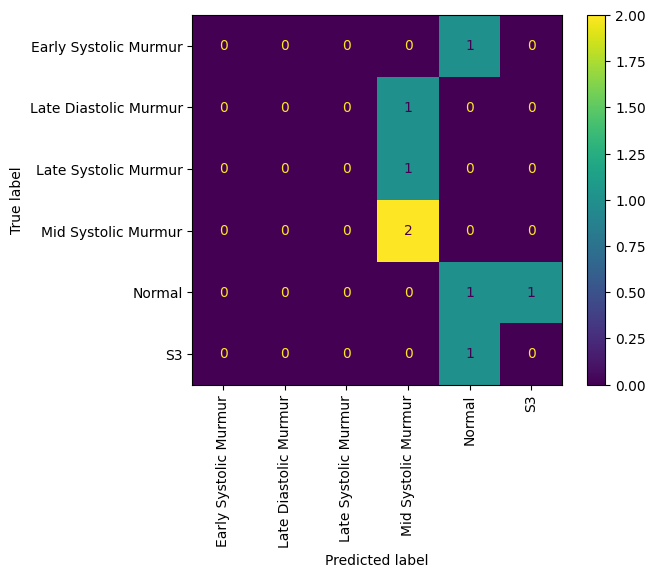

In [21]:
# confusion matrix
cm = confusion_matrix(
    truth,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(
    xticks_rotation=90
)

plt.show()

In [ ]:
# save model
torch.save(
    {
        "model_state_dict":
        model.state_dict(),

        "classes":
        encoder.classes_
    },
    "heart_cnn.pth"
)

print("Model saved.")